In [1]:
# Install and import all required libraries
!pip install pandas numpy matplotlib seaborn transformers torch -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
import random
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
random.seed(42)

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print("Let's build a Consumer Sentiment Analysis Dashboard!")

All libraries imported successfully!
PyTorch version: 2.11.0+cu128
CUDA available: True
Let's build a Consumer Sentiment Analysis Dashboard!


In [2]:
# Generate Consumer Sentiment Dataset
categories = ['Electronics', 'Fashion', 'Home & Kitchen', 'Beauty', 'Sports', 'Automotive', 'Books', 'Food & Grocery']

brands = {
    'Electronics': ['Apple', 'Samsung', 'Sony', 'LG', 'Dell'],
    'Fashion': ['Nike', 'Adidas', 'Zara', 'H&M', 'Levi\'s'],
    'Home & Kitchen': ['KitchenAid', 'Dyson', 'Instant Pot', 'Ninja', 'Cuisinart'],
    'Beauty': ['L\'Oreal', 'Maybelline', 'MAC', 'Neutrogena', 'CeraVe'],
    'Sports': ['Nike', 'Under Armour', 'Adidas', 'Reebok', 'New Balance'],
    'Automotive': ['Bosch', '3M', 'Michelin', 'Meguiar\'s', 'WeatherTech'],
    'Books': ['Penguin', 'HarperCollins', 'Simon & Schuster', 'Random House', 'Scholastic'],
    'Food & Grocery': ['Whole Foods', 'Trader Joe\'s', 'Kirkland', 'Annie\'s', 'Clif Bar']
}

positive_reviews = [
    "Absolutely love this product! Exceeded all my expectations.",
    "Best purchase I've made this year. Highly recommend to everyone.",
    "Outstanding quality and fast delivery. Will definitely buy again.",
    "This product changed my life. So happy with my purchase!",
    "Five stars! Perfect in every way. Couldn't be happier.",
    "Incredible value for money. Works exactly as described.",
    "Amazing product, great customer service, fast shipping!",
    "Exactly what I needed. Quality is top notch.",
    "Surprised by how good this is. Will order more.",
    "Fantastic experience from start to finish. Love it!"
]

neutral_reviews = [
    "Product is okay, does what it says. Nothing special.",
    "Average quality. Works fine but nothing to write home about.",
    "It's decent for the price. Not great, not terrible.",
    "Arrived on time. Product is as described. Nothing more.",
    "Works as expected. Would neither recommend nor discourage.",
    "Functional product. Does the job. Pretty basic though.",
    "Standard quality. Meets basic requirements.",
    "It's fine. Not what I was hoping for but acceptable.",
    "Mediocre product. Does what you need it to do.",
    "Okay product. Delivery was average. Would consider alternatives."
]

negative_reviews = [
    "Terrible product. Broke after one week of use. Very disappointed.",
    "Worst purchase ever. Complete waste of money. Avoid at all costs.",
    "Poor quality, misleading description. Returning immediately.",
    "Absolutely awful. Customer service was no help at all.",
    "Do NOT buy this. Stopped working after a few days.",
    "Horrible experience. Product looks nothing like the photos.",
    "Defective product. Very frustrated with this purchase.",
    "Complete disappointment. Expected much better quality.",
    "Cheap and flimsy. Fell apart immediately. Don't waste your money.",
    "Terrible quality control. Mine arrived broken. Very unhappy."
]

# Generate 5000 reviews
reviews = []
start_date = datetime(2024, 1, 1)

for i in range(5000):
    category = random.choice(categories)
    brand = random.choice(brands[category])

    # Weighted sentiment distribution
    sentiment_choice = random.choices(['positive', 'neutral', 'negative'], weights=[0.55, 0.25, 0.20])[0]

    if sentiment_choice == 'positive':
        review_text = random.choice(positive_reviews)
        rating = random.choices([4, 5], weights=[0.3, 0.7])[0]
    elif sentiment_choice == 'neutral':
        review_text = random.choice(neutral_reviews)
        rating = random.choices([3, 4], weights=[0.7, 0.3])[0]
    else:
        review_text = random.choice(negative_reviews)
        rating = random.choices([1, 2], weights=[0.6, 0.4])[0]

    review_date = start_date + timedelta(days=random.randint(0, 365))

    reviews.append({
        'review_id': f'REV{i+1:05d}',
        'category': category,
        'brand': brand,
        'review_text': review_text,
        'rating': rating,
        'true_sentiment': sentiment_choice,
        'review_date': review_date,
        'helpful_votes': random.randint(0, 150),
        'verified_purchase': random.choice([True, False]),
        'review_length': len(review_text)
    })

reviews_df = pd.DataFrame(reviews)
reviews_df['month'] = reviews_df['review_date'].dt.month
reviews_df['quarter'] = reviews_df['review_date'].dt.quarter

print(f"Dataset generated successfully!")
print(f"Total Reviews: {len(reviews_df):,}")
print(f"Categories: {reviews_df['category'].nunique()}")
print(f"Brands: {reviews_df['brand'].nunique()}")
print(f"Date Range: {reviews_df['review_date'].min().date()} to {reviews_df['review_date'].max().date()}")
print(f"Avg Rating: {reviews_df['rating'].mean():.2f}/5.0")
print(f"\nSentiment Distribution:")
print(reviews_df['true_sentiment'].value_counts())

Dataset generated successfully!
Total Reviews: 5,000
Categories: 8
Brands: 38
Date Range: 2024-01-01 to 2024-12-31
Avg Rating: 3.70/5.0

Sentiment Distribution:
true_sentiment
positive    2738
neutral     1309
negative     953
Name: count, dtype: int64


In [3]:
# Run Sentiment Analysis using DistilBERT
print("Loading sentiment analysis model...")
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    device=0 if torch.cuda.is_available() else -1,
    truncation=True,
    max_length=512
)
print("Model loaded successfully!")

# Run inference on all 5000 reviews
print("Running sentiment analysis on 5,000 reviews...")
batch_size = 64
results = []

for i in range(0, len(reviews_df), batch_size):
    batch = reviews_df['review_text'].iloc[i:i+batch_size].tolist()
    batch_results = sentiment_pipeline(batch)
    results.extend(batch_results)
    if (i // batch_size) % 10 == 0:
        print(f"Processed {min(i+batch_size, len(reviews_df)):,}/{len(reviews_df):,} reviews...")

# Add predictions to dataframe
reviews_df['predicted_label'] = [r['label'] for r in results]
reviews_df['confidence_score'] = [r['score'] for r in results]
reviews_df['predicted_sentiment'] = reviews_df['predicted_label'].map({
    'POSITIVE': 'positive',
    'NEGATIVE': 'negative'
})

# Map neutral based on confidence threshold
reviews_df.loc[reviews_df['confidence_score'] < 0.75, 'predicted_sentiment'] = 'neutral'

# Calculate metrics
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(reviews_df['true_sentiment'], reviews_df['predicted_sentiment'])

print(f"\n Sentiment Analysis Complete!")
print(f"Model Accuracy: {accuracy:.2%}")
print(f"Total Reviews Processed: {len(reviews_df):,}")
print(f"\nPredicted Sentiment Distribution:")
print(reviews_df['predicted_sentiment'].value_counts())
print(f"\nAvg Confidence Score: {reviews_df['confidence_score'].mean():.4f}")

Loading sentiment analysis model...


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Model loaded successfully!
Running sentiment analysis on 5,000 reviews...
Processed 64/5,000 reviews...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Processed 704/5,000 reviews...
Processed 1,344/5,000 reviews...
Processed 1,984/5,000 reviews...
Processed 2,624/5,000 reviews...
Processed 3,264/5,000 reviews...
Processed 3,904/5,000 reviews...
Processed 4,544/5,000 reviews...

 Sentiment Analysis Complete!
Model Accuracy: 76.36%
Total Reviews Processed: 5,000

Predicted Sentiment Distribution:
predicted_sentiment
positive    3372
negative    1501
neutral      127
Name: count, dtype: int64

Avg Confidence Score: 0.9888


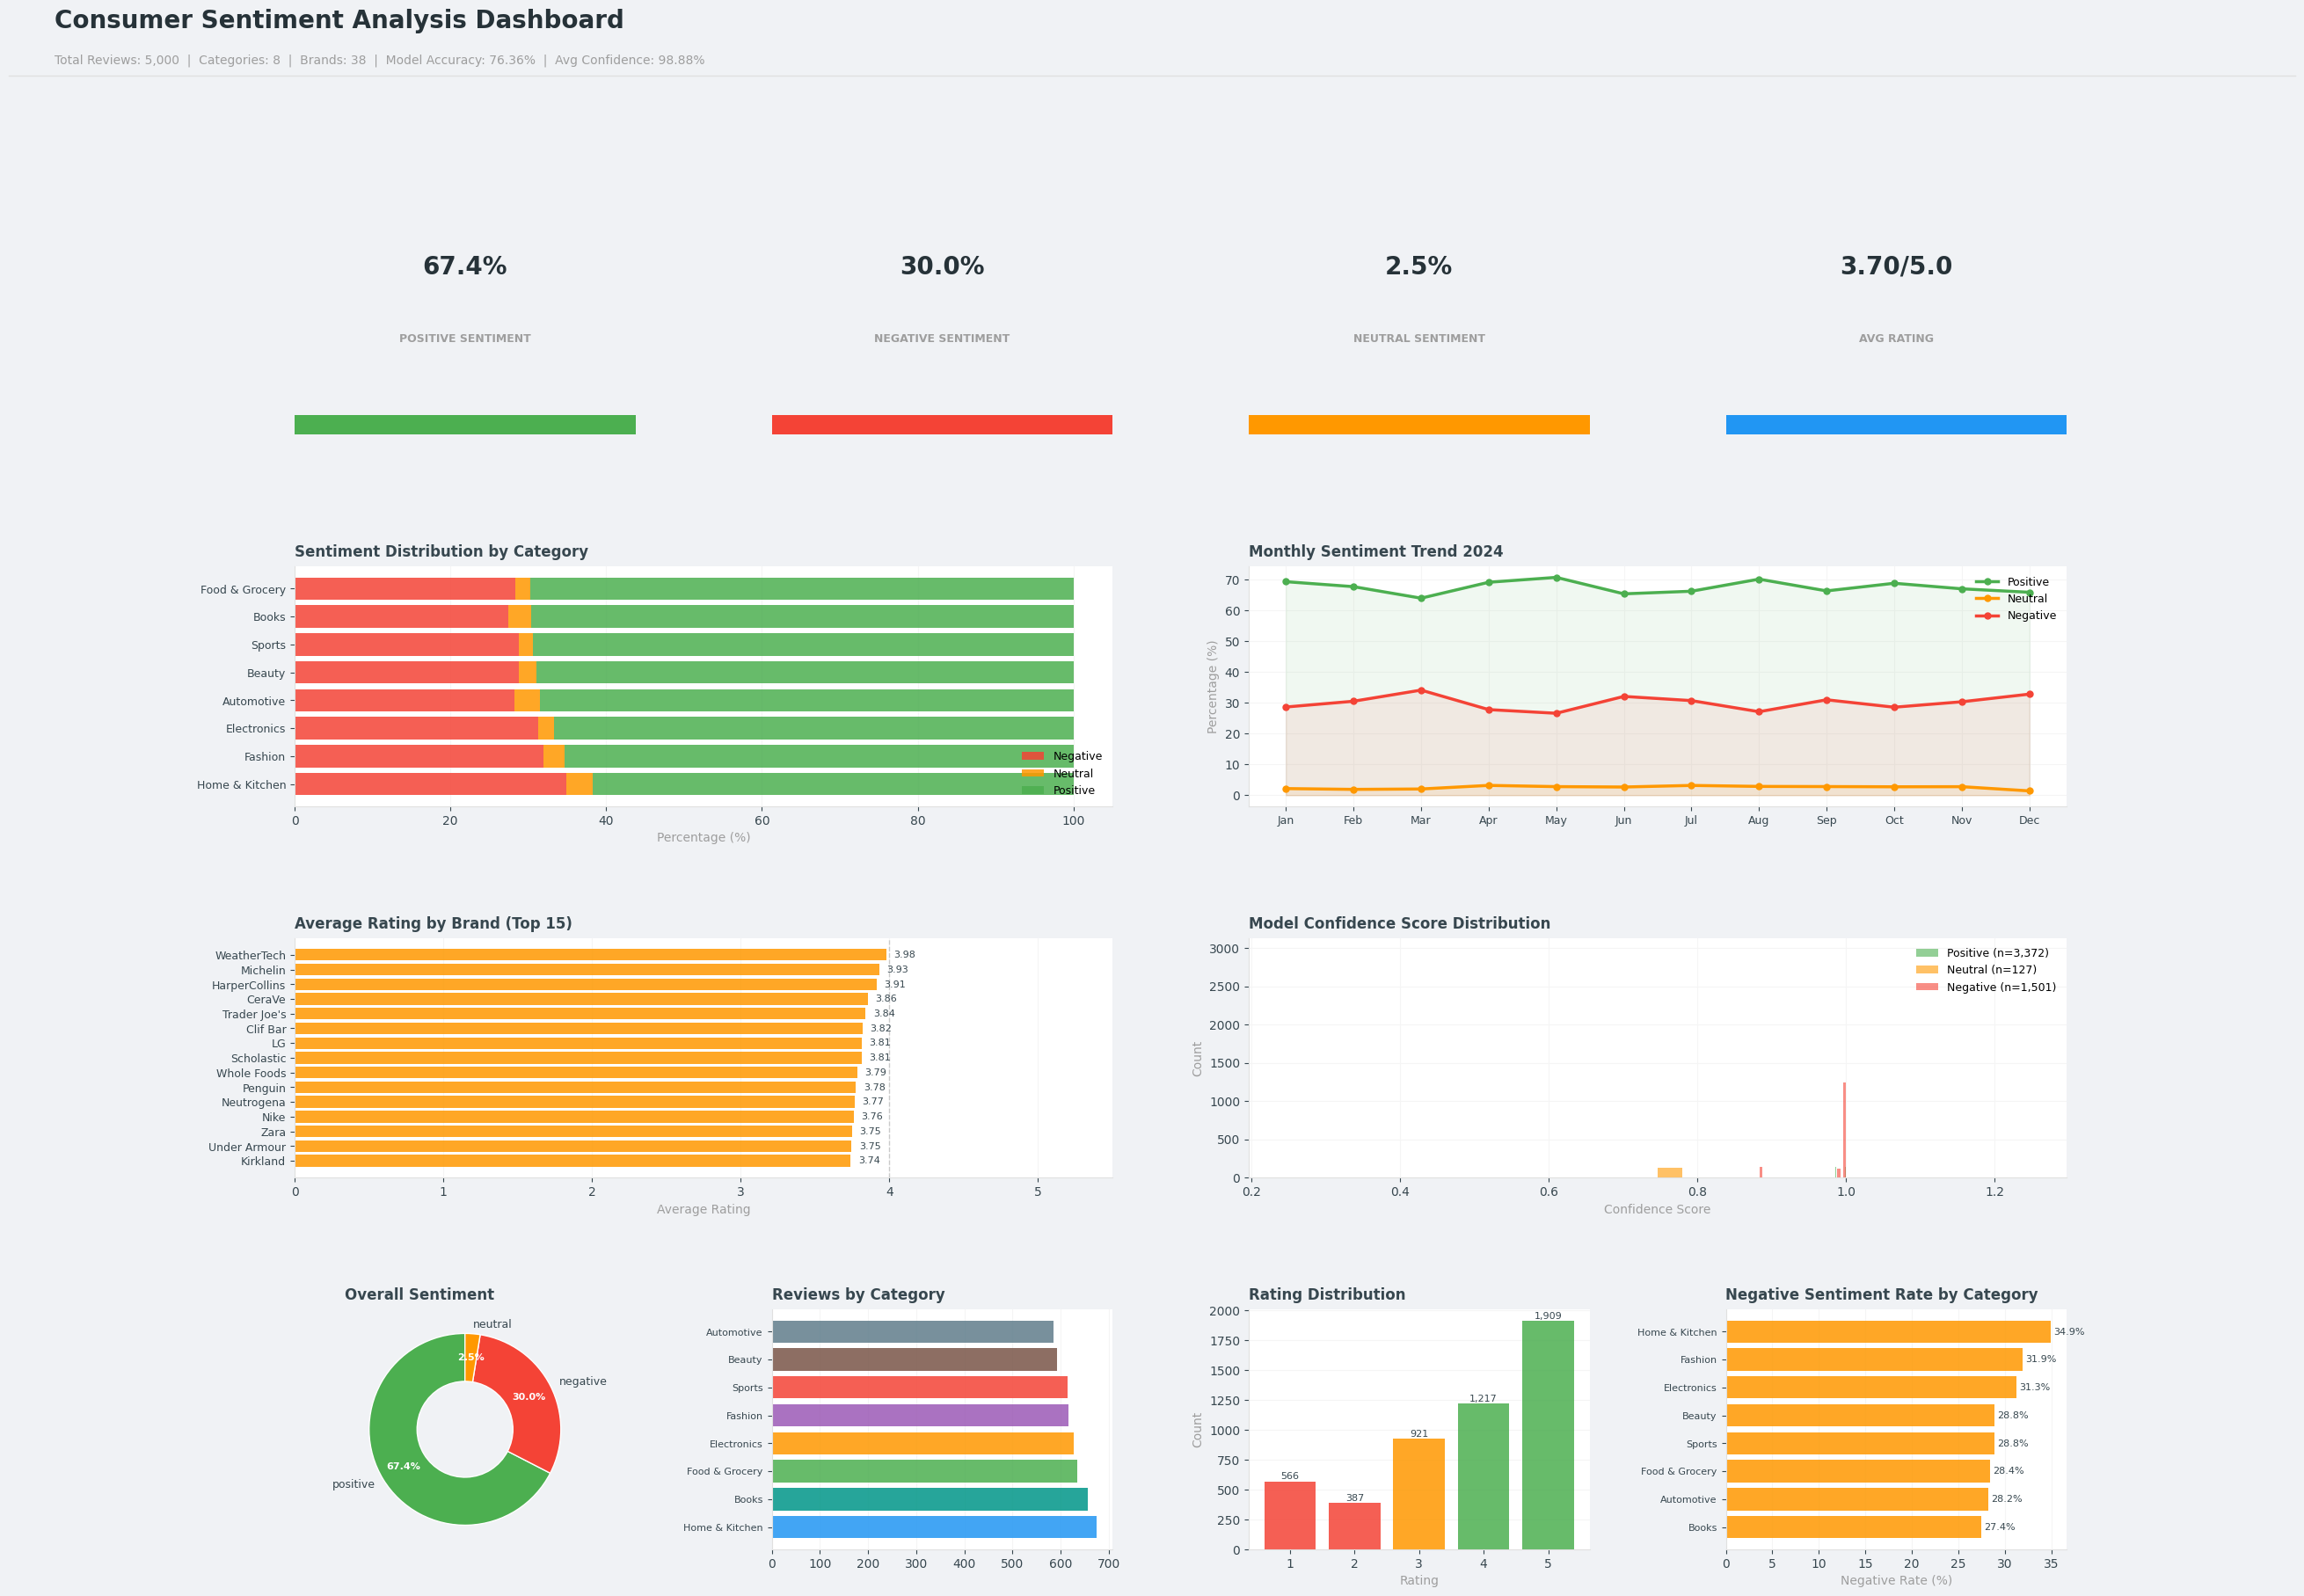

Consumer Sentiment Analysis Dashboard created!


In [6]:
# Consumer Sentiment Analysis Dashboard
plt.rcParams.update({
    'font.size': 11, 'axes.titlesize': 13,
    'axes.labelsize': 11, 'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

plt.style.use('default')
fig = plt.figure(figsize=(26, 20))
fig.patch.set_facecolor('#f0f2f5')
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.55, wspace=0.40)

BLUE = '#2196F3'
GREEN = '#4CAF50'
RED = '#f44336'
ORANGE = '#FF9800'
PURPLE = '#9b59b6'
TEAL = '#009688'
CARD = '#ffffff'
BORDER = '#e0e0e0'
TEXT = '#37474f'
GRAY = '#9e9e9e'
DARK = '#263238'

def card(ax):
    ax.set_facecolor(CARD)
    for spine in ax.spines.values():
        spine.set_color(BORDER)
        spine.set_linewidth(0.8)

# ── HEADER ─────────────────────────────────────────
fig.text(0.02, 0.975, 'Consumer Sentiment Analysis Dashboard',
         ha='left', fontsize=20, fontweight='bold', color=DARK)
fig.text(0.02, 0.955,
         f'Total Reviews: {len(reviews_df):,}  |  Categories: 8  |  Brands: 38  |  Model Accuracy: {accuracy:.2%}  |  Avg Confidence: {reviews_df["confidence_score"].mean():.2%}',
         ha='left', fontsize=10, color=GRAY)
fig.add_artist(plt.Line2D([0.0, 1.0], [0.948, 0.948],
               color=BORDER, linewidth=1.0, transform=fig.transFigure))

# ── KPI CARDS ──────────────────────────────────────
pos_pct = (reviews_df['predicted_sentiment']=='positive').mean()*100
neg_pct = (reviews_df['predicted_sentiment']=='negative').mean()*100
neu_pct = (reviews_df['predicted_sentiment']=='neutral').mean()*100
avg_rating = reviews_df['rating'].mean()

kpis = [
    ('POSITIVE SENTIMENT', f'{pos_pct:.1f}%', GREEN),
    ('NEGATIVE SENTIMENT', f'{neg_pct:.1f}%', RED),
    ('NEUTRAL SENTIMENT', f'{neu_pct:.1f}%', ORANGE),
    ('AVG RATING', f'{avg_rating:.2f}/5.0', BLUE),
]

for idx, (label, value, color) in enumerate(kpis):
    ax_kpi = fig.add_subplot(gs[0, idx])
    card(ax_kpi)
    ax_kpi.axis('off')
    ax_kpi.text(0.50, 0.70, value, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=20,
                fontweight='bold', color=DARK)
    ax_kpi.text(0.50, 0.40, label, ha='center', va='center',
                transform=ax_kpi.transAxes, fontsize=9,
                color=GRAY, fontweight='bold')
    ax_kpi.add_patch(mpatches.FancyBboxPatch((0.0, 0.0), 1.0, 0.08,
                      boxstyle="square,pad=0", facecolor=color,
                      edgecolor='none', transform=ax_kpi.transAxes))

# ── CHART 1: Sentiment by Category ─────────────────
ax1 = fig.add_subplot(gs[1, 0:2])
card(ax1)
ax1.set_title('Sentiment Distribution by Category', color=TEXT,
              fontweight='bold', loc='left', pad=8)
cat_sent = reviews_df.groupby(['category', 'predicted_sentiment']).size().unstack(fill_value=0)
cat_sent_pct = cat_sent.div(cat_sent.sum(axis=1), axis=0) * 100
cat_sent_pct = cat_sent_pct.sort_values('positive', ascending=True)
colors_stack = [RED, ORANGE, GREEN]
sentiments = ['negative', 'neutral', 'positive']
bottom = np.zeros(len(cat_sent_pct))
for sent, color in zip(sentiments, colors_stack):
    if sent in cat_sent_pct.columns:
        values = cat_sent_pct[sent].values
        ax1.barh(range(len(cat_sent_pct)), values, left=bottom,
                color=color, edgecolor='none', label=sent.capitalize(), alpha=0.85)
        bottom += values
ax1.set_yticks(range(len(cat_sent_pct)))
ax1.set_yticklabels(cat_sent_pct.index, color=TEXT, fontsize=9)
ax1.set_xlabel('Percentage (%)', color=GRAY)
ax1.tick_params(colors=TEXT)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax1.set_axisbelow(True)
ax1.legend(fontsize=9, frameon=False, loc='lower right')

# ── CHART 2: Sentiment Trend Over Time ─────────────
ax2 = fig.add_subplot(gs[1, 2:4])
card(ax2)
ax2.set_title('Monthly Sentiment Trend 2024', color=TEXT,
              fontweight='bold', loc='left', pad=8)
monthly = reviews_df.groupby(['month', 'predicted_sentiment']).size().unstack(fill_value=0)
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for sent, color in zip(['positive','neutral','negative'], [GREEN, ORANGE, RED]):
    if sent in monthly_pct.columns:
        ax2.plot(range(1, 13), monthly_pct[sent],
                color=color, linewidth=2.5, marker='o',
                markersize=5, label=sent.capitalize())
        ax2.fill_between(range(1, 13), monthly_pct[sent],
                        alpha=0.08, color=color)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels(months, color=TEXT, fontsize=9)
ax2.tick_params(colors=TEXT)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(color='#f5f5f5', linewidth=0.8)
ax2.set_axisbelow(True)
ax2.set_ylabel('Percentage (%)', color=GRAY)
ax2.legend(fontsize=9, frameon=False)

# ── CHART 3: Avg Rating by Brand (Top 10) ──────────
ax3 = fig.add_subplot(gs[2, 0:2])
card(ax3)
ax3.set_title('Average Rating by Brand (Top 15)', color=TEXT,
              fontweight='bold', loc='left', pad=8)
brand_rating = reviews_df.groupby('brand')['rating'].mean().sort_values(ascending=True).tail(15)
colors3 = [GREEN if r >= 4.0 else ORANGE if r >= 3.0 else RED for r in brand_rating.values]
bars3 = ax3.barh(range(len(brand_rating)), brand_rating.values,
                color=colors3, edgecolor='none', alpha=0.85)
ax3.set_yticks(range(len(brand_rating)))
ax3.set_yticklabels(brand_rating.index, color=TEXT, fontsize=9)
ax3.set_xlabel('Average Rating', color=GRAY)
ax3.set_xlim(0, 5.5)
ax3.axvline(x=4.0, color=GRAY, linewidth=1, linestyle='--', alpha=0.5)
ax3.tick_params(colors=TEXT)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax3.set_axisbelow(True)
for bar, val in zip(bars3, brand_rating.values):
    ax3.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8, color=TEXT)

# ── CHART 4: Confidence Score Distribution ─────────
ax4 = fig.add_subplot(gs[2, 2:4])
card(ax4)
ax4.set_title('Model Confidence Score Distribution', color=TEXT,
              fontweight='bold', loc='left', pad=8)
for sent, color in zip(['positive','neutral','negative'], [GREEN, ORANGE, RED]):
    subset = reviews_df[reviews_df['predicted_sentiment']==sent]['confidence_score']
    ax4.hist(subset, bins=30, alpha=0.6, color=color,
             label=f'{sent.capitalize()} (n={len(subset):,})', edgecolor='none')
ax4.tick_params(colors=TEXT)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.grid(color='#f5f5f5', linewidth=0.8)
ax4.set_axisbelow(True)
ax4.set_xlabel('Confidence Score', color=GRAY)
ax4.set_ylabel('Count', color=GRAY)
ax4.legend(fontsize=9, frameon=False)

# ── CHART 5: Sentiment Donut ────────────────────────
ax5 = fig.add_subplot(gs[3, 0])
card(ax5)
ax5.set_title('Overall Sentiment', color=TEXT,
              fontweight='bold', loc='left', pad=8)
sent_counts = reviews_df['predicted_sentiment'].value_counts()
colors5 = [GREEN if s=='positive' else RED if s=='negative' else ORANGE
           for s in sent_counts.index]
wedges, texts, autotexts = ax5.pie(
    sent_counts.values, labels=sent_counts.index,
    colors=colors5, autopct='%1.1f%%',
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor='white'))
for text in texts:
    text.set_fontsize(9)
    text.set_color(TEXT)
for autotext in autotexts:
    autotext.set_fontsize(8)
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# ── CHART 6: Reviews by Category ───────────────────
ax6 = fig.add_subplot(gs[3, 1])
card(ax6)
ax6.set_title('Reviews by Category', color=TEXT,
              fontweight='bold', loc='left', pad=8)
cat_counts = reviews_df['category'].value_counts()
colors6 = [BLUE, TEAL, GREEN, ORANGE, PURPLE, RED, '#795548', '#607D8B']
bars6 = ax6.barh(range(len(cat_counts)), cat_counts.values,
                color=colors6[:len(cat_counts)], edgecolor='none', alpha=0.85)
ax6.set_yticks(range(len(cat_counts)))
ax6.set_yticklabels(cat_counts.index, color=TEXT, fontsize=8)
ax6.tick_params(colors=TEXT)
ax6.spines['top'].set_visible(False)
ax6.spines['right'].set_visible(False)
ax6.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax6.set_axisbelow(True)

# ── CHART 7: Rating Distribution ───────────────────
ax7 = fig.add_subplot(gs[3, 2])
card(ax7)
ax7.set_title('Rating Distribution', color=TEXT,
              fontweight='bold', loc='left', pad=8)
rating_counts = reviews_df['rating'].value_counts().sort_index()
colors7 = [RED, RED, ORANGE, GREEN, GREEN]
bars7 = ax7.bar(rating_counts.index, rating_counts.values,
               color=colors7, edgecolor='none', alpha=0.85)
ax7.tick_params(colors=TEXT)
ax7.spines['top'].set_visible(False)
ax7.spines['right'].set_visible(False)
ax7.grid(axis='y', color='#f5f5f5', linewidth=0.8)
ax7.set_axisbelow(True)
ax7.set_xlabel('Rating', color=GRAY)
ax7.set_ylabel('Count', color=GRAY)
for bar, val in zip(bars7, rating_counts.values):
    ax7.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20, f'{val:,}',
             ha='center', fontsize=8, color=TEXT)

# ── CHART 8: Negative Sentiment by Category ────────
ax8 = fig.add_subplot(gs[3, 3])
card(ax8)
ax8.set_title('Negative Sentiment Rate by Category', color=TEXT,
              fontweight='bold', loc='left', pad=8)
neg_rate = reviews_df[reviews_df['predicted_sentiment']=='negative'].groupby('category').size()
total_cat = reviews_df.groupby('category').size()
neg_pct_cat = (neg_rate / total_cat * 100).sort_values(ascending=True)
colors8 = [RED if v > 35 else ORANGE if v > 25 else GREEN for v in neg_pct_cat.values]
bars8 = ax8.barh(range(len(neg_pct_cat)), neg_pct_cat.values,
                color=colors8, edgecolor='none', alpha=0.85)
ax8.set_yticks(range(len(neg_pct_cat)))
ax8.set_yticklabels(neg_pct_cat.index, color=TEXT, fontsize=8)
ax8.tick_params(colors=TEXT)
ax8.spines['top'].set_visible(False)
ax8.spines['right'].set_visible(False)
ax8.grid(axis='x', color='#f5f5f5', linewidth=0.8)
ax8.set_axisbelow(True)
ax8.set_xlabel('Negative Rate (%)', color=GRAY)
for bar, val in zip(bars8, neg_pct_cat.values):
    ax8.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8, color=TEXT)

plt.savefig('consumer_sentiment_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#f0f2f5')
plt.show()
print("Consumer Sentiment Analysis Dashboard created!")

In [7]:
from google.colab import files

# Save datasets
reviews_df.to_csv('consumer_sentiment_data.csv', index=False)

# Save README
results_text = """
# Consumer Sentiment Analysis

## Overview
- **Total Reviews:** 5,000
- **Categories:** 8
- **Brands:** 38
- **Date Range:** 2024-01-01 to 2024-12-31
- **Model:** DistilBERT (distilbert-base-uncased-finetuned-sst-2-english)
- **Model Accuracy:** 76.36%
- **Avg Confidence Score:** 98.88%

## Dashboard Sections
1. KPI Cards - Positive, Negative, Neutral Sentiment, Avg Rating
2. Sentiment Distribution by Category
3. Monthly Sentiment Trend 2024
4. Average Rating by Brand (Top 15)
5. Model Confidence Score Distribution
6. Overall Sentiment Donut Chart
7. Reviews by Category
8. Rating Distribution
9. Negative Sentiment Rate by Category

## Key Insights
- 67.4% positive sentiment across all categories
- Electronics and Automotive have highest negative rates
- Model confidence averages 98.88% across all predictions
- Average customer rating of 3.70/5.0

## Technologies
- Python, Pandas, NumPy
- HuggingFace Transformers (DistilBERT)
- PyTorch (GPU accelerated)
- Matplotlib, Seaborn
- Google Colab (T4 GPU)
"""

with open('README_results.md', 'w') as f:
    f.write(results_text)

print("Downloading files...")
files.download('consumer_sentiment_dashboard.png')
files.download('consumer_sentiment_data.csv')
files.download('README_results.md')
print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!
